<a href="https://colab.research.google.com/github/rohith154-vsr/ML-2-LAB/blob/main/LP_3_FINDS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Loading Car Evaluation dataset...
Dataset loaded successfully!

Dataset shape: (1728, 7)

First 5 rows:
  buying  maint doors persons lug_boot safety Target
0  vhigh  vhigh     2       2    small    low  unacc
1  vhigh  vhigh     2       2    small    med  unacc
2  vhigh  vhigh     2       2    small   high  unacc
3  vhigh  vhigh     2       2      med    low  unacc
4  vhigh  vhigh     2       2      med    med  unacc

Columns:
['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety', 'Target']

Target classes:
Target
unacc    1210
acc       384
good       69
vgood      65
Name: count, dtype: int64

Missing values:
buying      0
maint       0
doors       0
persons     0
lug_boot    0
safety      0
Target      0
dtype: int64


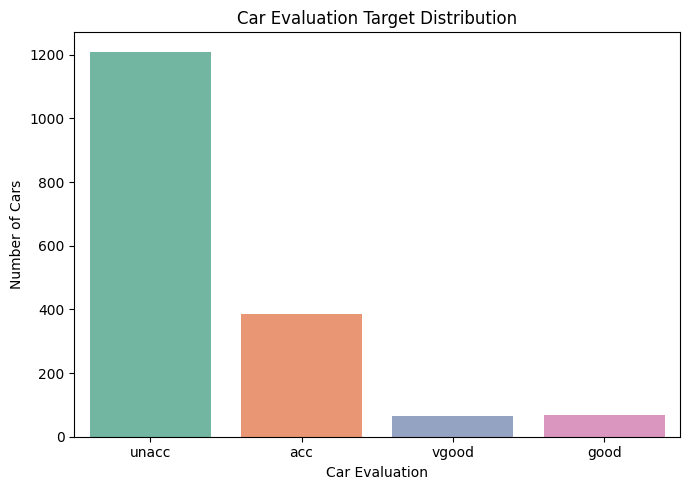


Positive class: vgood
Positive examples: 65

First 10 positive examples:
     buying maint  doors persons lug_boot safety
1097    med   med      2       4      big   high
1106    med   med      2    more      big   high
1124    med   med      3       4      big   high
1130    med   med      3    more      med   high
1133    med   med      3    more      big   high
1148    med   med      4       4      med   high
1151    med   med      4       4      big   high
1157    med   med      4    more      med   high
1160    med   med      4    more      big   high
1175    med   med  5more       4      med   high

HYPOTHESIS AFTER EACH POSITIVE EXAMPLE
   buying maint doors persons lug_boot safety
1     med   med     2       4      big   high
2     med   med     2       ?      big   high
3     med   med     ?       ?      big   high
4     med   med     ?       ?        ?   high
5     med   med     ?       ?        ?   high
6     med   med     ?       ?        ?   high
7     med   med     ?    

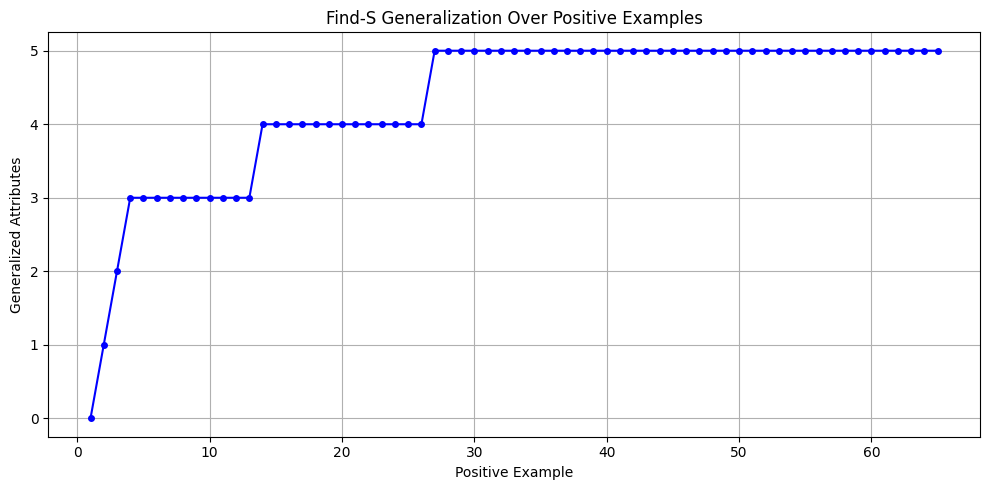


FINAL HYPOTHESIS SUMMARY
Total attributes      : 6
Specific attributes   : 1
Generalized attributes: 5


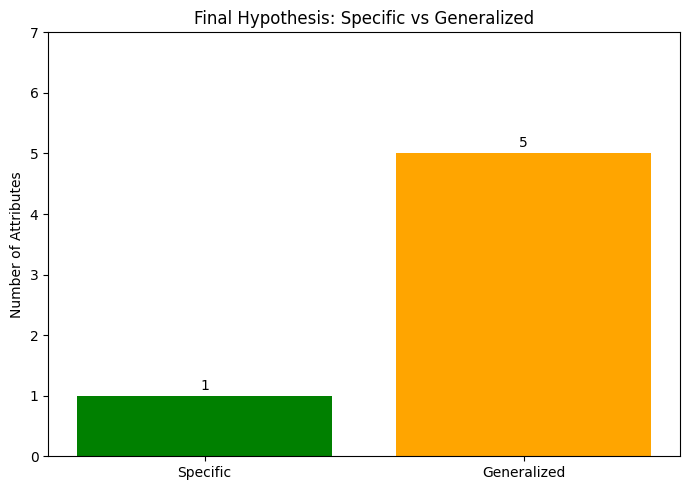

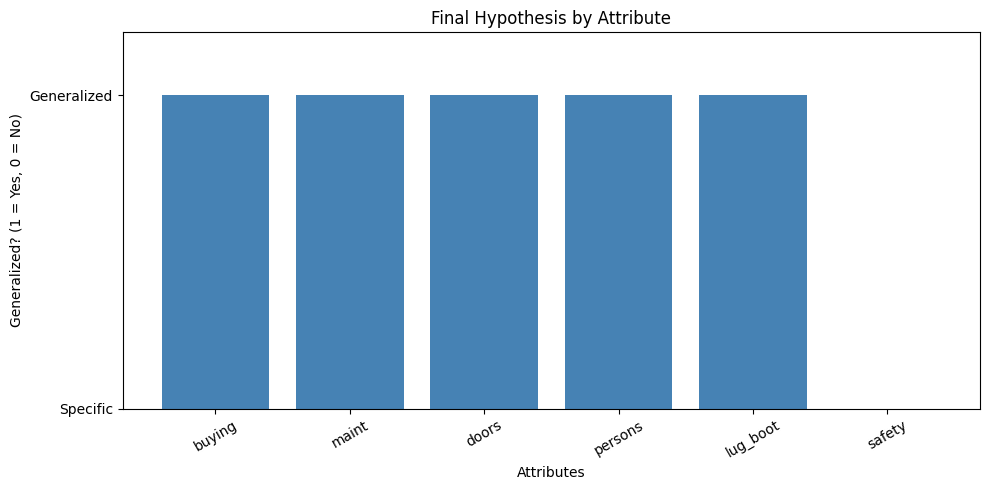


FINAL HYPOTHESIS ATTRIBUTE-WISE
buying       : ?
maint        : ?
doors        : ?
persons      : ?
lug_boot     : ?
safety       : high

           FINAL SUMMARY
Dataset size        : (1728, 7)
Positive class      : vgood
Positive examples   : 65
Number of features  : 6
Specific attributes : 1
Generalized         : 5

Final Find-S Hypothesis:
buying = ?
maint = ?
doors = ?
persons = ?
lug_boot = ?
safety = high

        PROGRAM COMPLETED


In [2]:
# ============================================================
# CAR EVALUATION DATASET - FIND-S ALGORITHM
# GOOGLE COLAB VERSION
# NO CSV FILE REQUIRED
# ============================================================

# Install required package
!pip -q install ucimlrepo


# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo


# ============================================================
# 2. LOAD CAR EVALUATION DATASET DIRECTLY FROM UCI
# ============================================================

print("Loading Car Evaluation dataset...")

car_evaluation = fetch_ucirepo(id=19)

# Get features
X = car_evaluation.data.features.copy()

# Get target
y = car_evaluation.data.targets.copy()

print("Dataset loaded successfully!")


# ============================================================
# 3. PREPARE DATASET
# ============================================================

# Rename columns to match your original program
X.columns = [
    "buying",
    "maint",
    "doors",
    "persons",
    "lug_boot",
    "safety"
]

# Convert target to Series
y = y.iloc[:, 0]

# Create final DataFrame
df = X.copy()
df["Target"] = y


# ============================================================
# 4. DISPLAY DATASET INFORMATION
# ============================================================

print("\nDataset shape:", df.shape)

print("\nFirst 5 rows:")
print(df.head())

print("\nColumns:")
print(df.columns.tolist())

print("\nTarget classes:")
print(df["Target"].value_counts())

print("\nMissing values:")
print(df.isnull().sum())


# ============================================================
# 5. TARGET DISTRIBUTION
# ============================================================

plt.figure(figsize=(7, 5))

sns.countplot(
    x="Target",
    data=df,
    hue="Target",
    palette="Set2",
    legend=False
)

plt.title("Car Evaluation Target Distribution")
plt.xlabel("Car Evaluation")
plt.ylabel("Number of Cars")

plt.tight_layout()
plt.show()


# ============================================================
# 6. DEFINE FEATURES
# ============================================================

features = [
    "buying",
    "maint",
    "doors",
    "persons",
    "lug_boot",
    "safety"
]


# ============================================================
# 7. SELECT POSITIVE EXAMPLES
# Find-S considers "vgood" as the positive class
# ============================================================

positive_class = "vgood"

positive_data = df[
    df["Target"] == positive_class
].copy()

print("\nPositive class:", positive_class)
print("Positive examples:", len(positive_data))

print("\nFirst 10 positive examples:")
print(
    positive_data[features].head(10)
)


# ============================================================
# 8. FIND-S ALGORITHM
# ============================================================

# Start with the most specific hypothesis
hypothesis = ["Ø"] * len(features)

# Store hypothesis after each positive example
history = []


for _, row in positive_data.iterrows():

    example = [
        row[feature]
        for feature in features
    ]

    # First positive example
    if hypothesis == ["Ø"] * len(features):

        hypothesis = example.copy()

    else:

        # Generalize when values are different
        for i in range(len(hypothesis)):

            if hypothesis[i] != example[i]:

                hypothesis[i] = "?"

    # Save hypothesis
    history.append(
        hypothesis.copy()
    )


# ============================================================
# 9. HYPOTHESIS HISTORY
# ============================================================

history_df = pd.DataFrame(
    history,
    columns=features
)

history_df.index = range(
    1,
    len(history_df) + 1
)

print("\n====================================")
print("HYPOTHESIS AFTER EACH POSITIVE EXAMPLE")
print("====================================")

print(history_df.head(15))


# ============================================================
# 10. FINAL HYPOTHESIS
# ============================================================

print("\n====================================")
print("FINAL FIND-S HYPOTHESIS")
print("====================================")

print(hypothesis)


# ============================================================
# 11. GENERALIZATION OVER POSITIVE EXAMPLES
# ============================================================

generalization_history = history_df.apply(
    lambda row: (row == "?").sum(),
    axis=1
)

plt.figure(figsize=(10, 5))

plt.plot(
    range(1, len(generalization_history) + 1),
    generalization_history,
    marker="o",
    markersize=4,
    color="blue"
)

plt.xlabel("Positive Example")
plt.ylabel("Generalized Attributes")

plt.title(
    "Find-S Generalization Over Positive Examples"
)

plt.grid(True)

plt.tight_layout()
plt.show()


# ============================================================
# 12. SPECIFIC VS GENERALIZED ATTRIBUTES
# ============================================================

specific_count = (
    len(hypothesis)
    - hypothesis.count("?")
)

generalized_count = hypothesis.count("?")

print("\n====================================")
print("FINAL HYPOTHESIS SUMMARY")
print("====================================")

print("Total attributes      :", len(hypothesis))
print("Specific attributes   :", specific_count)
print("Generalized attributes:", generalized_count)


plt.figure(figsize=(7, 5))

bars = plt.bar(
    ["Specific", "Generalized"],
    [specific_count, generalized_count],
    color=["green", "orange"]
)

plt.title(
    "Final Hypothesis: Specific vs Generalized"
)

plt.ylabel("Number of Attributes")

for bar, value in zip(
    bars,
    [specific_count, generalized_count]
):

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.1,
        str(value),
        ha="center"
    )

plt.ylim(0, len(features) + 1)

plt.tight_layout()
plt.show()


# ============================================================
# 13. FINAL HYPOTHESIS BY ATTRIBUTE
# ============================================================

generalized_values = [
    1 if value == "?" else 0
    for value in hypothesis
]

plt.figure(figsize=(10, 5))

plt.bar(
    features,
    generalized_values,
    color="steelblue"
)

plt.xlabel("Attributes")

plt.ylabel(
    "Generalized? (1 = Yes, 0 = No)"
)

plt.title(
    "Final Hypothesis by Attribute"
)

plt.xticks(
    rotation=30
)

plt.yticks(
    [0, 1],
    ["Specific", "Generalized"]
)

plt.ylim(0, 1.2)

plt.tight_layout()
plt.show()


# ============================================================
# 14. FINAL HYPOTHESIS ATTRIBUTE-WISE
# ============================================================

print("\n====================================")
print("FINAL HYPOTHESIS ATTRIBUTE-WISE")
print("====================================")

for feature, value in zip(
    features,
    hypothesis
):

    print(
        f"{feature:12s} : {value}"
    )


# ============================================================
# 15. FINAL SUMMARY
# ============================================================

print("\n====================================")
print("           FINAL SUMMARY")
print("====================================")

print("Dataset size        :", df.shape)
print("Positive class      :", positive_class)
print("Positive examples   :", len(positive_data))
print("Number of features  :", len(features))
print("Specific attributes :", specific_count)
print("Generalized         :", generalized_count)

print("\nFinal Find-S Hypothesis:")

for feature, value in zip(
    features,
    hypothesis
):

    print(f"{feature} = {value}")

print("\n====================================")
print("        PROGRAM COMPLETED")
print("====================================")
